# Сборный проект-5

Необходимо разработать демонстрационную версию поиска изображений по запросу.

Для демонстрационной версии нужно обучить модель, которая получит векторное представление изображения, векторное представление текста, а на выходе выдаст число от 0 до 1 — покажет, насколько текст и картинка подходят друг другу.

### Описание данных

Данные доступны по [ссылке](https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip).


В файле `train_dataset.csv` находится информация, необходимая для обучения: имя файла изображения, идентификатор описания и текст описания. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `train_images` содержатся изображения для тренировки модели.

В файле `CrowdAnnotations.tsv` — данные по соответствию изображения и описания, полученные с помощью краудсорсинга. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.
3. Доля людей, подтвердивших, что описание соответствует изображению.
4. Количество человек, подтвердивших, что описание соответствует изображению.
5. Количество человек, подтвердивших, что описание не соответствует изображению.

В файле `ea.tsv` содержатся данные по соответствию изображения и описания, полученные в результате опроса экспертов. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.

3, 4, 5 — оценки трёх экспертов.

Эксперты ставят оценки по шкале от 1 до 4, где 1 — изображение и запрос совершенно не соответствуют друг другу, 2 — запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует, 3 — запрос и текст соответствуют с точностью до некоторых деталей, 4 — запрос и текст соответствуют полностью.

В файле `test_queries.csv` находится информация, необходимая для тестирования: идентификатор запроса, текст запроса и релевантное изображение. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `test_images` содержатся изображения для тестирования модели.

## 1. Исследовательский анализ данных

Наш датасет содержит экспертные и краудсорсинговые оценки соответствия текста и изображения.

В файле с экспертными мнениями для каждой пары изображение-текст имеются оценки от трёх специалистов. Для решения задачи вы должны эти оценки агрегировать — превратить в одну. Существует несколько способов агрегации оценок, самый простой — голосование большинства: за какую оценку проголосовала большая часть экспертов (в нашем случае 2 или 3), та оценка и ставится как итоговая. Поскольку число экспертов меньше числа классов, может случиться, что каждый эксперт поставит разные оценки, например: 1, 4, 2. В таком случае данную пару изображение-текст можно исключить из датасета.

Вы можете воспользоваться другим методом агрегации оценок или придумать свой.

В файле с краудсорсинговыми оценками информация расположена в таком порядке:

1. Доля исполнителей, подтвердивших, что текст **соответствует** картинке.
2. Количество исполнителей, подтвердивших, что текст **соответствует** картинке.
3. Количество исполнителей, подтвердивших, что текст **не соответствует** картинке.

После анализа экспертных и краудсорсинговых оценок выберите либо одну из них, либо объедините их в одну по какому-то критерию: например, оценка эксперта принимается с коэффициентом 0.6, а крауда — с коэффициентом 0.4.

Ваша модель должна возвращать на выходе вероятность соответствия изображения тексту, поэтому целевая переменная должна иметь значения от 0 до 1.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import transformers
import pickle
import time
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import catboost
import requests
import zipfile
import io
import re
import optuna


from tqdm import tqdm, notebook
from textwrap import wrap
from torch import cuda
from torch.utils.data import DataLoader, Dataset, TensorDataset
from PIL import Image
from torchvision import datasets, transforms, models
from torchmetrics import MeanSquaredError
from sklearn.metrics import roc_auc_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit,  GridSearchCV
from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer, AutoModel
from catboost import CatBoostRegressor
from sentence_transformers import SentenceTransformer


b:\py\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rnd = 123123
DEVICE = torch.device('cuda')


In [3]:
torch.cuda.is_available()

True

In [4]:
# Создаем директорию для данных
DATA_PATH = './data'
os.makedirs(DATA_PATH, exist_ok=True)

# Скачиваем архив
url = "https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip"
print("Скачиваем датасет...")
response = requests.get(url)
print("Датасет скачан")

# Распаковываем архив
print("Распаковываем архив...")
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall(DATA_PATH)
print("Архив успешно распакован")

Скачиваем датасет...
Датасет скачан
Распаковываем архив...
Архив успешно распакован


In [5]:
DATA_PATH = DATA_PATH + '/to_upload'

SAVE_PATH = os.path.join(DATA_PATH, 'pickles')
os.makedirs(SAVE_PATH, exist_ok=True)


def save_pkl(data, file_name):
    path = os.path.join(SAVE_PATH, f'{file_name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f'Saved to {path}')

def load_pkl(file_name):
    path = os.path.join(SAVE_PATH, f'{file_name}.pkl')
    with open(path, 'rb') as f:
        return pickle.load(f)

In [6]:
print("Директория data существует:", os.path.exists('./data'))
print("Содержимое директории data:", os.listdir('./data') if os.path.exists('./data') else "Директория не существует")

Директория data существует: True
Содержимое директории data: ['to_upload', '__MACOSX']


In [7]:
train_dataset = pd.read_csv(DATA_PATH + '/train_dataset.csv')
train_dataset.sample(5, random_state=rnd)

,image,query_id,query_text
1258,3334537556_a2cf4e9b9a.jpg,3541474181_489f19fae7.jpg#2,A snowboarder in the air over a snowy mountain .
866,2196107384_361d73a170.jpg,3729525173_7f984ed776.jpg#2,A woman is reading literature and sitting on t...
639,3518126579_e70e0cbb2b.jpg,2228022180_9597b2a458.jpg#2,Group of children in blue uniforms sitting on ...
590,1408958345_68eea9a4e4.jpg,339350939_6643bfb270.jpg#2,A dog is running along the beach beside the oc...
1837,2103568100_5d018c495b.jpg,197107117_4b438b1872.jpg#2,A rock climber climbs in between two very larg...


In [8]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image       5822 non-null   object
 1   query_id    5822 non-null   object
 2   query_text  5822 non-null   object
dtypes: object(3)
memory usage: 136.6+ KB


In [9]:
test_queries = pd.read_csv(DATA_PATH + '/test_queries.csv', sep='|', index_col=[0])
test_queries.sample(5, random_state=rnd)

,query_id,query_text,image
258,3170110692_d1e0e66cee.jpg#3,A man and a woman wear funny masks and pretend...,3170110692_d1e0e66cee.jpg
239,3122579598_14841c038a.jpg#4,Two kids playing with a dog .,3122579598_14841c038a.jpg
194,2986716822_e220754d32.jpg#4,The brown German shepherd dog is playing with ...,2986716822_e220754d32.jpg
90,2399219552_bbba0a9a59.jpg#0,A boy plays basketball .,2399219552_bbba0a9a59.jpg
211,3044359043_627488ddf0.jpg#1,A dog is jumping into a pool for a swim compet...,3044359043_627488ddf0.jpg


In [10]:
test_queries.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   query_id    500 non-null    object
 1   query_text  500 non-null    object
 2   image       500 non-null    object
dtypes: object(3)
memory usage: 15.6+ KB


In [11]:
test_images = pd.read_csv(DATA_PATH + '/test_images.csv')
test_images.sample(5, random_state=rnd)

,image
21,3330333217_1a69497a74.jpg
50,2399551242_c62a46dd5f.jpg
62,3119913014_688d4997d7.jpg
72,269650644_059a84ece5.jpg
98,2670637584_d96efb8afa.jpg


In [12]:
test_images.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   100 non-null    object
dtypes: object(1)
memory usage: 932.0+ bytes


In [13]:
ea = pd.read_csv(DATA_PATH + '/ExpertAnnotations.tsv', sep='\t', header=None)
ea.columns = ['image', 'query_id', '1', '2', '3']
ca = pd.read_csv(DATA_PATH + '/CrowdAnnotations.tsv', sep='\t', header=None)
ca.columns = ['image', 'query_id', 'conf_rate', 'confirm', 'not_confirm']

In [14]:
ea.sample(5, random_state = rnd)

,image,query_id,1,2,3
1258,2370481277_a3085614c9.jpg,3545652636_0746537307.jpg#2,2,3,3
866,2176980976_7054c99621.jpg,3325497914_f9014d615b.jpg#2,1,1,2
639,197504190_fd1fc3d4b7.jpg,2101457132_69c950bc45.jpg#2,1,2,2
590,1808370027_2088394eb4.jpg,3461041826_0e24cdf597.jpg#2,3,3,3
1837,2602258549_7401a3cdae.jpg,2870875612_2cbb9e4a3c.jpg#2,1,1,1


In [15]:
ea.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image     5822 non-null   object
 1   query_id  5822 non-null   object
 2   1         5822 non-null   int64 
 3   2         5822 non-null   int64 
 4   3         5822 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 227.6+ KB


In [16]:
ca.sample(5, random_state = rnd)

,image,query_id,conf_rate,confirm,not_confirm
9731,2346401538_f5e8da66fc.jpg,2588927489_f4da2f11ec.jpg#2,0.000000,0,3
47435,909808296_23c427022d.jpg,2410320522_d967f0b75c.jpg#2,0.000000,0,3
43432,466956209_2ffcea3941.jpg,3429956016_3c7e3096c2.jpg#2,0.333333,1,2
25438,3138399980_d6ab8b2272.jpg,532457586_bddfc5251d.jpg#2,0.000000,0,3
39187,3613424631_3ae537624f.jpg,3256275785_9c3af57576.jpg#2,0.000000,0,3


In [17]:
ca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47830 entries, 0 to 47829
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   image        47830 non-null  object 
 1   query_id     47830 non-null  object 
 2   conf_rate    47830 non-null  float64
 3   confirm      47830 non-null  int64  
 4   not_confirm  47830 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.8+ MB


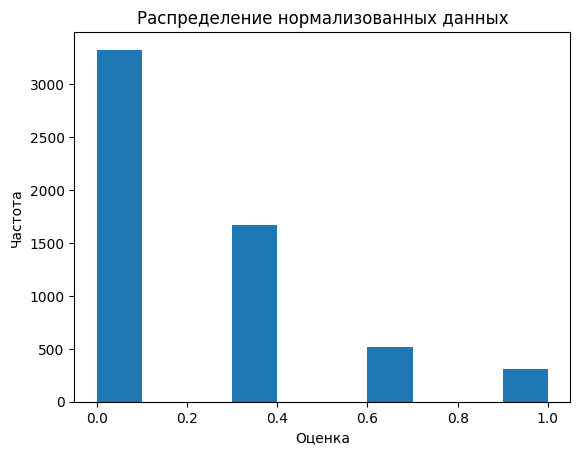

In [18]:
ea['exp_total'] = (ea[['1', '2', '3']]).median(axis=1)

# применим методы нормализации по столбцу 'exp_total'
ea['exp_norm'] = (ea['exp_total'] - ea['exp_total'].min()) / (ea['exp_total'].max() - ea['exp_total'].min())

# просмотрим нормализованные данные
ea['exp_norm'].plot.hist()
plt.title('Распределение нормализованных данных')
plt.xlabel('Оценка')
plt.ylabel('Частота')
plt.show()

In [19]:
ea.head()

,image,query_id,1,2,3,exp_total,exp_norm
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1,1.0,0.000000
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2,1.0,0.000000
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2,1.0,0.000000
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2,2.0,0.333333
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2,1.0,0.000000


In [20]:
# созадим новый датасет для обучения на основе имеющихся файлов данных
train_data = train_dataset\
.merge(ea[['image', 'query_id', 'exp_norm']], how='left', on=['image', 'query_id'])\
.merge(ca[['image', 'query_id', 'conf_rate']], how='outer', on=['image', 'query_id'])

In [21]:
train_data.sample(10)

,image,query_id,query_text,exp_norm,conf_rate
2082,136552115_6dc3e7231c.jpg,219070971_ae43410b9e.jpg#2,NaN,NaN,0.0
48216,514990193_2d2422af2c.jpg,2445283938_ff477c7952.jpg#2,NaN,NaN,0.0
29115,3203453897_6317aac6ff.jpg,2351479551_e8820a1ff3.jpg#2,NaN,NaN,0.0
462,1122944218_8eb3607403.jpg,3545586120_283d728a97.jpg#2,NaN,NaN,0.0
30547,3234115903_f4dfc8fc75.jpg,3585487286_ef9a8d4c56.jpg#2,NaN,NaN,0.0
7759,2194286203_5dc620006a.jpg,2480850054_de3433b54a.jpg#2,NaN,NaN,0.0
24400,3019842612_8501c1791e.jpg,3609645320_815c294b65.jpg#2,NaN,NaN,0.0
45142,401079494_562454c4d6.jpg,745880539_cd3f948837.jpg#2,NaN,NaN,0.0
33063,3323988406_e3c8fce690.jpg,2393264648_a280744f97.jpg#2,NaN,NaN,0.0
525,1131800850_89c7ffd477.jpg,3549583146_3e8bb2f7e9.jpg#2,A young boy is riding a bike .,0.0,NaN


In [22]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51323 entries, 0 to 51322
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       51323 non-null  object 
 1   query_id    51323 non-null  object 
 2   query_text  5822 non-null   object 
 3   exp_norm    5822 non-null   float64
 4   conf_rate   47830 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.0+ MB


In [23]:
query_id_text_corresp = train_dataset[['query_id', 'query_text']].drop_duplicates()

In [24]:
train_data = train_data.drop(columns=['query_text']).merge(query_id_text_corresp, how="left", on=['query_id'])

In [25]:
# я решил, что стоит предать оценкам экспертов больший вес
w_exp, w_crowd = 0.6, 0.4

exp   = train_data['exp_norm']
crowd = train_data['conf_rate']

train_data['target'] = np.where(
    exp.notna() & crowd.notna(),
    (exp*w_exp + crowd*w_crowd) / (w_exp + w_crowd),
    exp.fillna(crowd)
)

train_data = train_data.drop(columns=['exp_norm','conf_rate'])

In [26]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51323 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       51323 non-null  object 
 1   query_id    51323 non-null  object 
 2   query_text  50214 non-null  object 
 3   target      51323 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.6+ MB


In [27]:
train_data['query_text']= train_data['query_text'].str.lower()

In [28]:
train_data.sample(10)

,image,query_id,query_text,target
2163,136644343_0e2b423829.jpg,909191414_1cf5d85821.jpg#2,a young boy jumping in front of a young girl a...,0.000000
18464,2718024196_3ff660416a.jpg,2757803246_8aa3499d26.jpg#2,a little boy is running towards a group of peo...,0.000000
22649,2938120171_970564e3d8.jpg,317383917_d8bfa350b6.jpg#2,three black dogs and a white dog are standing ...,0.000000
14076,2505988632_9541f15583.jpg,3484832904_08619300d9.jpg#2,a girl playing softball takes a strike .,0.200000
51131,96420612_feb18fc6c6.jpg,2594902417_f65d8866a8.jpg#2,"the two tan colored dogs are in a field , and ...",0.000000
33745,3354330935_de75be9d2f.jpg,2100816230_ff866fb352.jpg#2,a man jumps while snow skiing .,0.666667
30948,3244747165_17028936e0.jpg,3427118504_93126c83e0.jpg#2,NaN,0.000000
35533,3416091866_a96003d652.jpg,791338571_7f38510bf7.jpg#2,a red car parked next to a cow in a field .,0.000000
6310,2089426086_7acc98a3a8.jpg,2295216243_0712928988.jpg#2,friends and family dance on a beach by their v...,0.000000
33834,3354883962_170d19bfe4.jpg,3216926094_bc975e84b9.jpg#2,a dog running with a blue toy in its mouth .,0.000000


In [29]:
train_data.isnull().sum()

image            0
query_id         0
query_text    1109
target           0
dtype: int64

In [30]:
train_data.dropna(axis = 'index', inplace = True)
train_data.isnull().sum()

image         0
query_id      0
query_text    0
target        0
dtype: int64

In [31]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50214 entries, 0 to 51322
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       50214 non-null  object 
 1   query_id    50214 non-null  object 
 2   query_text  50214 non-null  object 
 3   target      50214 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.9+ MB


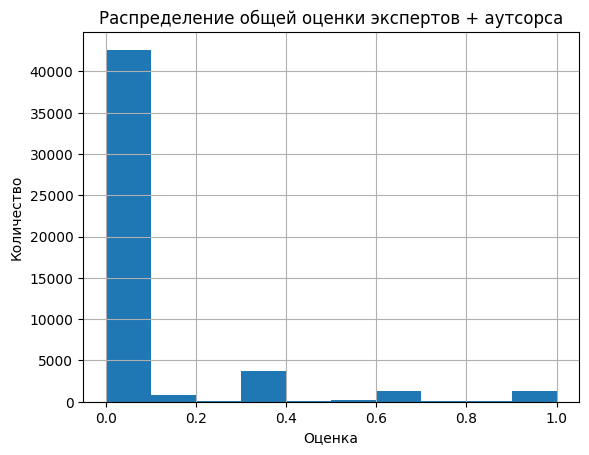

In [32]:
train_data['target'].hist()
plt.title('Распределение общей оценки экспертов + аутсорса')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.show()

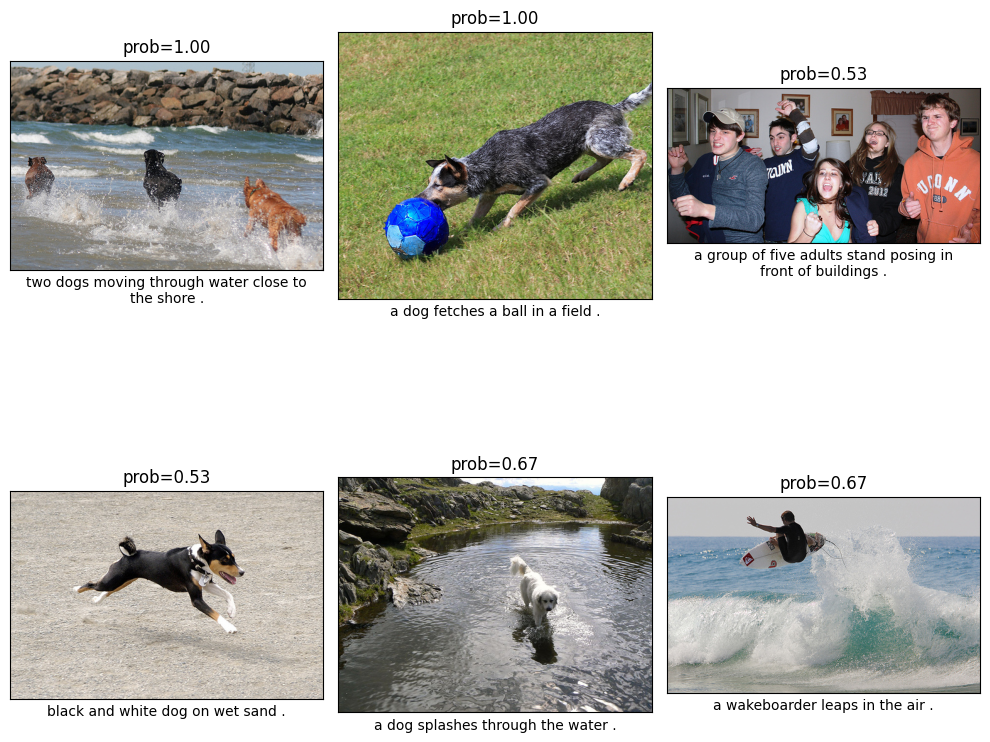

In [33]:
sample_data = train_data.sample(n=2000, random_state=0)

pos = sample_data[sample_data['target'] >= 0.5].head(8)


fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.flatten()
for ax, (_, row) in zip(axes, pos.iterrows()):
    img_path = os.path.join(DATA_PATH, 'train_images', row['image'])
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(f"prob={row['target']:.2f}")
    label = '\n'.join(wrap(row['query_text'], 40))
    ax.set_xlabel(label)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

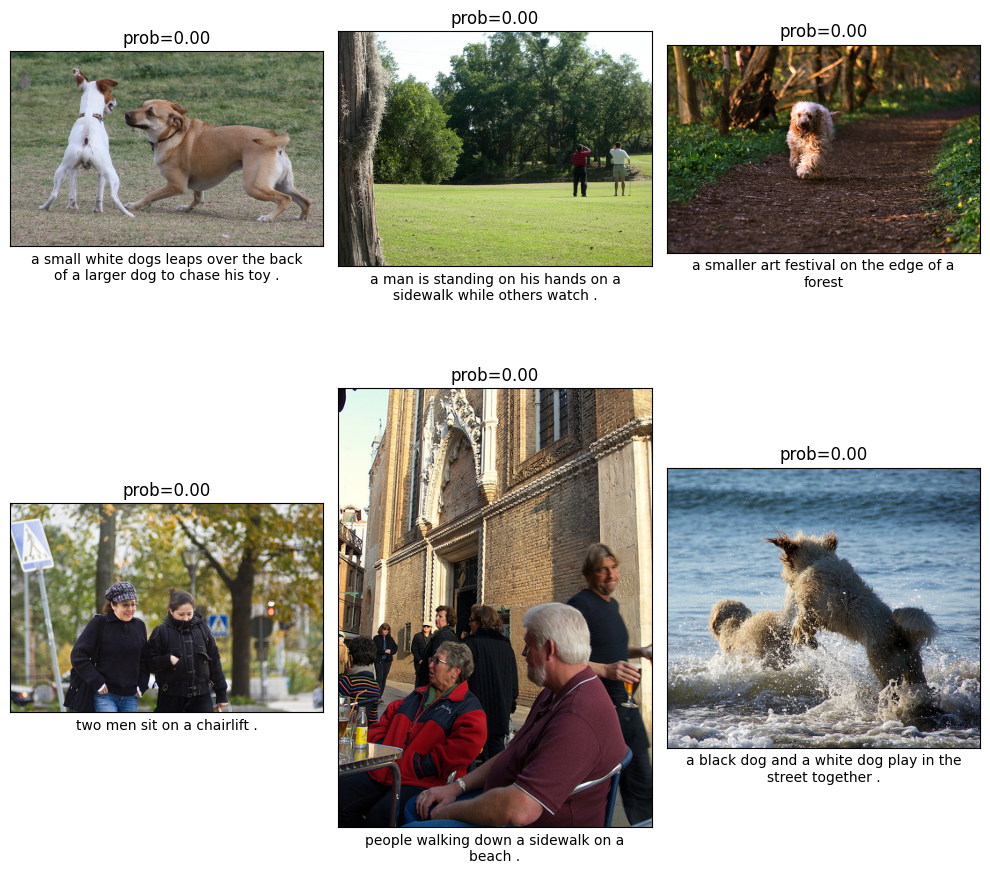

In [34]:

neg = sample_data[sample_data['target'] <= 0.5].head(8)


fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.flatten()
for ax, (_, row) in zip(axes, neg.iterrows()):

    img_path = os.path.join(DATA_PATH, 'train_images', row['image'])
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(f"prob={row['target']:.2f}")
    label = '\n'.join(wrap(row['query_text'], 40))
    ax.set_xlabel(label)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

### Выводы по загрузке и анализу данных
На этом этапе были импортированы библиотеки, импортированы датасеты, проведён анализ имеющихся данных. Из представленных данных была собрана единая таблица для обучения с акцентом на мнение экспертов. Оценки были нормированы.

По построенным графикам можно утверждать, что большинство фото не соответствуют описанию.

## 2. Проверка данных

В некоторых странах, где работает ваша компания, действуют ограничения по обработке изображений: поисковым сервисам и сервисам, предоставляющим возможность поиска, запрещено без разрешения родителей или законных представителей предоставлять любую информацию, в том числе, но не исключительно тексты, изображения, видео и аудио, содержащие описание, изображение или запись голоса детей. Ребёнком считается любой человек, не достигший 16 лет.

В вашем сервисе строго следуют законам стран, в которых работают. Поэтому при попытке посмотреть изображения, запрещённые законодательством, вместо картинок показывается дисклеймер:

> This image is unavailable in your country in compliance with local laws
>

Однако у вас в PoC нет возможности воспользоваться данным функционалом. Поэтому все изображения, которые нарушают данный закон, нужно удалить из обучающей выборки.

In [35]:
stop_word = ['child',
            'kid', 
            'minor', 
            'youth', 
            'toddler', 
            'infant', 
            'baby', 
            'newborn', 
            'preschooler', 
            'schoolchild', 
            'teen',
            'teenager', 
            'preteen', 
            'adolescent', 
            'juvenile', 
            'youngster', 
            'pupil', 
            'dependent', 
            'ward', 
            'boy', 
            'girls',
            'boys',
            'kids',
            'babys',
            'teens',
            'childs',
            'girl' ]

In [36]:
# Фильтрация всех строк, где в query_text встречается хотя бы одно стоп-слов

pattern = r'\b(' + '|'.join(map(re.escape, stop_word)) + r')\b'

# метка строк, которые нужно удалить
mask = train_data['query_text'].str.contains(pattern, case=False, regex=True, na=False)

print(f"Удаляем {mask.sum()} строк(у) с запрещёнными словами в описании")

# отфильтровываем и сбрасываем индекс
train_data_clear = train_data.loc[~mask].reset_index(drop=True)

C:\Users\inwoond\AppData\Local\Temp\ipykernel_19788\2086999028.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = train_data['query_text'].str.contains(pattern, case=False, regex=True, na=False)


Удаляем 12911 строк(у) с запрещёнными словами в описании


In [37]:
initial_count = len(train_data)

mask_bad = train_data['query_text'].str.contains(pattern, case=False, regex=True, na=False)
train_data['img_id'] = train_data['query_id'].str.split('#').str[0]
bad_imgs = set(train_data.loc[mask_bad, 'img_id'])
train_data_clear = train_data[~train_data['img_id'].isin(bad_imgs)].reset_index(drop=True)

removed_count = initial_count - len(train_data_clear)
print(f"Удалено {removed_count} строк с плохими изображениями")


C:\Users\inwoond\AppData\Local\Temp\ipykernel_19788\279312638.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_bad = train_data['query_text'].str.contains(pattern, case=False, regex=True, na=False)


Удалено 12911 строк с плохими изображениями


### Вывод

На этом этапе был составлен список из запрещённых слов и были удалены 496 строк.

## 3. Векторизация изображений

Перейдём к векторизации изображений.

Самый примитивный способ — прочесть изображение и превратить полученную матрицу в вектор. Такой способ нам не подходит: длина векторов может быть сильно разной, так как размеры изображений разные. Поэтому стоит обратиться к свёрточным сетям: они позволяют "выделить" главные компоненты изображений. Как это сделать? Нужно выбрать какую-либо архитектуру, например ResNet-18, посмотреть на слои и исключить полносвязные слои, которые отвечают за конечное предсказание. При этом можно загрузить модель данной архитектуры, предварительно натренированную на датасете ImageNet.

Векторизацию изображений произведём через resnet50

In [38]:
train_data_clear = train_data_clear.drop('query_id', axis=1)

In [39]:
def image_to_tensor(image_names, data):
    # 1. Загрузка и подготовка модели
    model = models.resnet50(pretrained=True)
    model = nn.Sequential(*list(model.children())[:-1]).to(DEVICE)
    model.eval()
    for p in model.parameters(): p.requires_grad_(False)

    # 2. Преобразования для входа
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],
                             std=[0.229,0.224,0.225]),
    ])

    folder = 'train_images' if data=='train' else 'test_images'
    output_vectors = []
    for img_name in image_names.values:
        img = Image.open(f"{DATA_PATH}/{folder}/{img_name}").convert('RGB')
        x = preprocess(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            vec = model(x).flatten().cpu().numpy()
        output_vectors.append(vec)
        torch.cuda.empty_cache()
    return np.vstack(output_vectors)


In [40]:
train_vec_img = image_to_tensor(image_names=train_data_clear['image'], data='train')
save_pkl(train_vec_img, 'train_vec_img')

b:\py\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
b:\py\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Saved to ./data/to_upload\pickles\train_vec_img.pkl


In [41]:
train_vec_img.shape

(37303, 2048)

### Вывод
Была произведена векторизация изображений, полученный датасет имеет размерность 37303, 2048

## 4. Векторизация текстов

Следующий этап — векторизация текстов. Вы можете поэкспериментировать с несколькими способами векторизации текстов:

- tf-idf
- word2vec
- \*трансформеры (например Bert)

\* — если вы изучали трансформеры в спринте Машинное обучение для текстов.


Векторизацию текстов произведём через BERT

In [42]:
def text_to_vectors(texts_series):
    tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
    model = transformers.BertModel.from_pretrained('bert-base-uncased')
    model.to(DEVICE)
    model.eval()

    # Токенизация и паддинг
    encoded = texts_series.apply(
        lambda x: tokenizer.encode(x, add_special_tokens=True, truncation=True)
    )
    max_len = max(len(ids) for ids in encoded)
    padded = np.array([ids + [tokenizer.pad_token_id] * (max_len - len(ids)) 
                       for ids in encoded])
    attention_mask = (padded != tokenizer.pad_token_id).astype(int)

    # Преобразование в тензоры
    input_ids = torch.tensor(padded, dtype=torch.long).to(DEVICE)
    attention_mask = torch.tensor(attention_mask, dtype=torch.long).to(DEVICE)

    # Бэтчинг и извлечение CLS-эмбеддингов
    batch_size = 100
    embeddings = []
    for i in range((len(input_ids) + batch_size - 1) // batch_size):
        batch_ids = input_ids[i*batch_size:(i+1)*batch_size]
        batch_mask = attention_mask[i*batch_size:(i+1)*batch_size]
        with torch.no_grad():
            outputs = model(batch_ids, attention_mask=batch_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_emb)
        torch.cuda.empty_cache()

    return np.vstack(embeddings)


In [43]:
train_vec_text = text_to_vectors(train_data_clear['query_text'])
save_pkl(train_vec_text, 'train_vec_text')

Saved to ./data/to_upload\pickles\train_vec_text.pkl


In [44]:
train_vec_text.shape

(37303, 768)

### Вывод
Провел векторизацию текста, получив датасет размерностью (37303,768)

## 5. Объединение векторов

Подготовьте данные для обучения: объедините векторы изображений и векторы текстов с целевой переменной.

In [45]:
try:
    features = load_pkl('features')
    target = load_pkl('target')
    train_data_clear = load_pkl('train_data_clear (1)')
except:
    features = np.concatenate([train_vec_img, train_vec_text], axis=1)
    target = train_data_clear.target.values
    save_pkl(features, 'features')
    save_pkl(target, 'target')
    save_pkl(train_data_clear, 'train_data_clear')


Saved to ./data/to_upload\pickles\features.pkl
Saved to ./data/to_upload\pickles\target.pkl
Saved to ./data/to_upload\pickles\train_data_clear.pkl


In [46]:
print("Размер данных", features.shape)
print(target.shape)

Размер данных (37303, 2816)
(37303,)


### Вывод

В результате векторизации было получено 37303 объекта с 2816 признаками для одного объекта

## 6. Обучение модели предсказания соответствия

Для обучения разделите датасет на тренировочную и тестовую выборки. Простое случайное разбиение не подходит: нужно исключить попадание изображения и в обучающую, и в тестовую выборки.
Для того чтобы учесть изображения при разбиении, можно воспользоваться классом [GroupShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html) из библиотеки sklearn.model_selection.

Код ниже разбивает датасет на тренировочную и тестовую выборки в пропорции 7:3 так, что строки с одинаковым значением 'group_column' будут содержаться либо в тестовом, либо в тренировочном датасете.

```
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, train_size=.7, random_state=42)
train_indices, test_indices = next(gss.split(X=df.drop(columns=['target']), y=df['target'], groups=df['group_column']))
train_df, test_df = df.loc[train_indices], df.loc[test_indices]

```

Какую модель использовать — выберите самостоятельно. Также вам предстоит выбрать метрику качества либо реализовать свою.

RMSE для непрерывного таргета в [0,1] — подходящий выбор: она напрямую отражает среднеквадратичную ошибку наших вероятностей.


In [47]:
gss = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

train_indices, valid_indices = next(gss.split(features, target, groups=train_data_clear["image"].values))

X_train = features[train_indices]
y_train = target[train_indices]
X_valid = features[valid_indices]
y_valid = target[valid_indices]

In [48]:
print('Размер тренировочной выборки:', X_train.shape)
print('Размер валидационной выборки:', X_valid.shape)

Размер тренировочной выборки: (29903, 2816)
Размер валидационной выборки: (7400, 2816)


Проведена разбивка на тренировочную и валидационную выборки

In [49]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

In [50]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_pred = lin_model.predict(X_valid_scaled)
rmse_valid = np.sqrt(mean_squared_error(y_valid, lin_pred))
print(rmse_valid)

0.2106193546869167


In [51]:
model_cb = CatBoostRegressor(random_state = rnd, verbose=False)
# cb_params = {
#     'iterations': [600],
#     'depth': [1, 2, 3],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'l2_leaf_reg': [1, 3, 5, 10],
#     'bagging_temperature': [0.1, 0.5, 1.0],
#     'border_count': [32, 64, 128]
# }
cb_params = {
    'iterations': [600],
    'depth': [3],
    'learning_rate': [0.01],
    'l2_leaf_reg': [1],
    'bagging_temperature': [0.1],
    'border_count': [64]
}

cat = GridSearchCV(estimator=model_cb, param_grid=cb_params, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
cat.fit(X_train_scaled, y_train)

GridSearchCV(cv=3,
             estimator=<catboost.core.CatBoostRegressor object at 0x0000025D7B05A270>,
             n_jobs=-1,
             param_grid={'bagging_temperature': [0.1], 'border_count': [64],
                         'depth': [3], 'iterations': [600], 'l2_leaf_reg': [1],
                         'learning_rate': [0.01]},
             scoring='neg_root_mean_squared_error')

In [52]:
print(cat.best_params_)
print(cat.best_score_)

{'bagging_temperature': 0.1, 'border_count': 64, 'depth': 3, 'iterations': 600, 'l2_leaf_reg': 1, 'learning_rate': 0.01}
-0.21410910142845818


In [53]:
y_pred = torch.tensor(cat.predict(X_valid_scaled), dtype=torch.float32).to(DEVICE)
y_true = torch.tensor(y_valid, dtype=torch.float32).to(DEVICE)

# Вычисляем RMSE
rmse_metric = MeanSquaredError(squared=False).to(DEVICE)
rmse = rmse_metric(y_pred, y_true)
print(f"RMSE: {rmse.item():.4f}")


RMSE: 0.2060


In [54]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(DEVICE)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(DEVICE)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32).to(DEVICE)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.float32).view(-1, 1).to(DEVICE)

In [55]:
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
valid_ds = TensorDataset(X_valid_tensor, y_valid_tensor)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=64)


In [57]:
# вывел сюда лучшие параметры
#best_params = {'lr': 4.5322993717696885e-05, 'dropout': 0.48548022500083865, 'hidden1': 185, 'hidden2': 78}

model = nn.Sequential(
    nn.Linear(2816, 185),
    nn.BatchNorm1d(185), nn.ReLU(), nn.Dropout(0.48548022500083865),
    nn.Linear(185, 78),
    nn.BatchNorm1d(78), nn.ReLU(), nn.Dropout(0.48548022500083865),
    nn.Linear(78, 1)
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=4.5322993717696885e-05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)
criterion = nn.MSELoss()


In [58]:
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        criterion(model(xb), yb).backward()
        optimizer.step()
    model.eval()
    val_rmse = np.sqrt(mean_squared_error(
        y_valid, 
        np.concatenate([model(xv.to(DEVICE)).cpu().detach().numpy().flatten() for xv, _ in valid_loader])
    ))
    scheduler.step(val_rmse)
    print(f'Epoch {epoch+1}/{num_epochs} — Valid RMSE: {val_rmse:.4f}')


Epoch 1/100 — Valid RMSE: 0.2520
Epoch 2/100 — Valid RMSE: 0.2304
Epoch 3/100 — Valid RMSE: 0.2227
Epoch 4/100 — Valid RMSE: 0.2167
Epoch 5/100 — Valid RMSE: 0.2132
Epoch 6/100 — Valid RMSE: 0.2103
Epoch 7/100 — Valid RMSE: 0.2092
Epoch 8/100 — Valid RMSE: 0.2083
Epoch 9/100 — Valid RMSE: 0.2080
Epoch 10/100 — Valid RMSE: 0.2081
Epoch 11/100 — Valid RMSE: 0.2071
Epoch 12/100 — Valid RMSE: 0.2067
Epoch 13/100 — Valid RMSE: 0.2068
Epoch 14/100 — Valid RMSE: 0.2069
Epoch 15/100 — Valid RMSE: 0.2061
Epoch 16/100 — Valid RMSE: 0.2052
Epoch 17/100 — Valid RMSE: 0.2054
Epoch 18/100 — Valid RMSE: 0.2048
Epoch 19/100 — Valid RMSE: 0.2034
Epoch 20/100 — Valid RMSE: 0.2035
Epoch 21/100 — Valid RMSE: 0.2027
Epoch 22/100 — Valid RMSE: 0.2029
Epoch 23/100 — Valid RMSE: 0.2028
Epoch 24/100 — Valid RMSE: 0.2019
Epoch 25/100 — Valid RMSE: 0.2023
Epoch 26/100 — Valid RMSE: 0.2006
Epoch 27/100 — Valid RMSE: 0.1999
Epoch 28/100 — Valid RMSE: 0.2004
Epoch 29/100 — Valid RMSE: 0.2011
Epoch 30/100 — Valid RM

In [59]:
model.eval()
total_loss = 0
for xb, yb in valid_loader:
    with torch.no_grad():
        pred = model(xb)
        total_loss += mean_squared_error(yb.cpu().numpy(), pred.cpu().numpy()) * xb.size(0)
rmse = np.sqrt(total_loss / len(valid_ds))
print(f'Valid RMSE: {rmse:.4f}')

def predict(model, X_scaled, device=DEVICE):
    model.eval()
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model(X_tensor).cpu().numpy().flatten()
    return preds

predictions = predict(model, X_valid_scaled)
print("Predictions:", predictions)


Valid RMSE: 0.1979
Predictions: [-0.01197521 -0.00408217  0.16522819 ...  0.36703542  0.21892354
  0.08040161]


### Вывод
Было обучено три модели: 
1. Линейная регрессия 
2. CatBoosting
3. Полносвязная нейронная сеть

По результатам обучения было выявлено, что лучшую метрику RMSE  даёт полносвязная нейронная сеть (около 0.198), будем использовать её


## 7. Тестирование модели

Настало время протестировать модель. Для этого получите эмбеддинги для всех тестовых изображений из папки `test_images`, выберите случайные 10 запросов из файла `test_queries.csv` и для каждого запроса выведите наиболее релевантное изображение. Сравните визуально качество поиска.

In [60]:
test_images_vectors = image_to_tensor(image_names=test_images['image'], data='test')
random_queries = test_queries['query_text'].sample(10, random_state=rnd)

test_images_vectors.shape

b:\py\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
b:\py\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


(100, 2048)

Проведена векторизация тестовых данных

In [61]:
save_pkl(test_images_vectors, 'test_images_vectors')

Saved to ./data/to_upload\pickles\test_images_vectors.pkl


In [62]:
test_images_vectors = load_pkl('test_images_vectors')

In [63]:
random_queries = test_queries['query_text'].sample(10, random_state=0)

In [64]:
# Функция, которая показывает дисклеймер, если описание попадает под ограничения
def show_disclaimer(string, stop_word):
    stop_word = stop_word
    lst = string.split(' ')
    if len(set(lst).intersection(set(stop_word))) != 0:
        print('You asked for:', string)
        print('This image is unavailable in your country in compliance with local laws.')
        return True
    else:
        return False

# Функция, которая выводит наиболее релевантные изображения по текстовому запросу
def show_related_images(query):
    text = query
    disclaimer = show_disclaimer(text.values[0], stop_word)
    if not disclaimer:
        # Переводим текст в вектор.
        text_vector = text_to_vectors(text)
        # Получаем массив с вектором текста, с количеством строк равным количеству изображений.
        text_vector_array = np.full((test_images_vectors.shape[0], text_vector.shape[1]), text_vector)
        # Конкатенируем вектора всех ихображений с ветором текста описания и переводим в тензор
        
        image_text_vectors = np.concatenate([test_images_vectors, text_vector_array], axis=1)

        # Предсказываем вероятность совпадения текста и изображения для всех изображений и данного текста описания
        model.eval()
        X_t = torch.tensor(image_text_vectors, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            preds_tensor = model(X_t)                # тензор на DEVICE
        pred = preds_tensor.cpu().numpy().flatten()

        # Получаем индексы четырех самых высоких вероятностей
        ind = np.argpartition(pred, -4)[-4:]
        # Получаем четрыре самые высокие вероятности
        top_probs = pred[ind]
        # Получаем четыре изображения, для которых модель предсказала наиболее вероятное совпадение с текстом
        top_images = test_images.values[ind].flatten()

        # Выводим изображения на экран
        fig = plt.figure(figsize=(5, 5))
        plt.suptitle(*text.values, y=1.05)
        for i in range(4):
            fig.add_subplot(2, 2, i+1)
            img_name = top_images[i]
            img_target = top_probs[i]
            img = mpimg.imread(f'{DATA_PATH}/test_images/{img_name}')
            plt.imshow(img)
            plt.xlabel(f'prob={img_target}')
            plt.xticks([])
            plt.yticks([])
            plt.tight_layout()
        plt.show()

You asked for: A boy plays basketball .
This image is unavailable in your country in compliance with local laws.


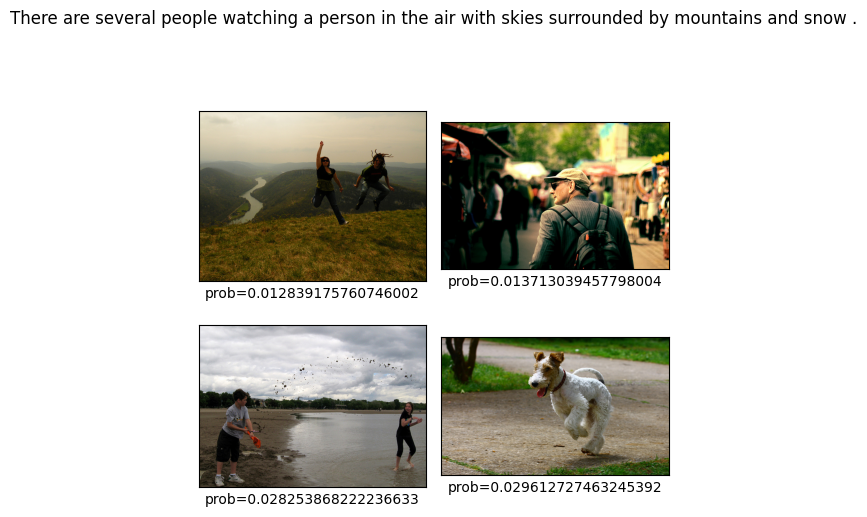

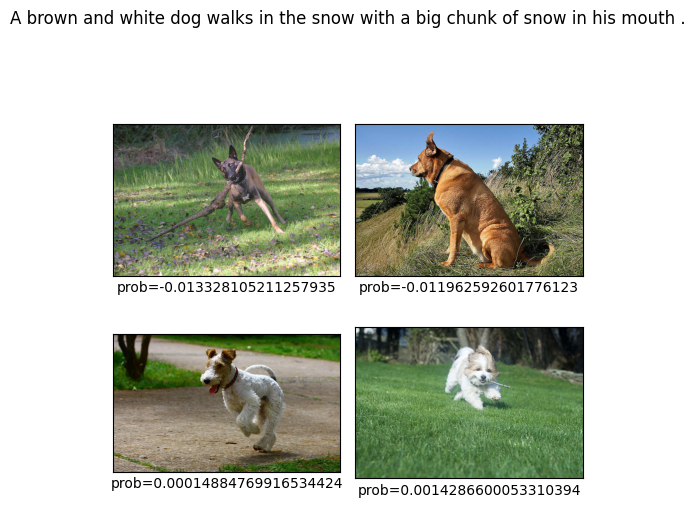

You asked for: A man and two boys standing in spraying water .
This image is unavailable in your country in compliance with local laws.


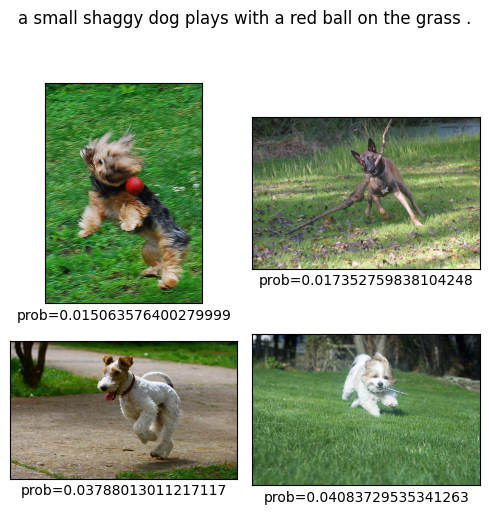

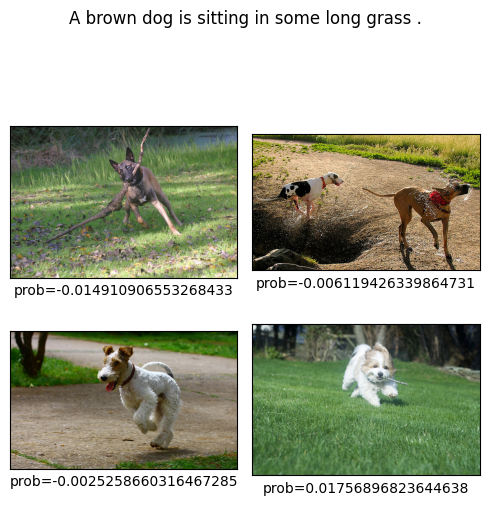

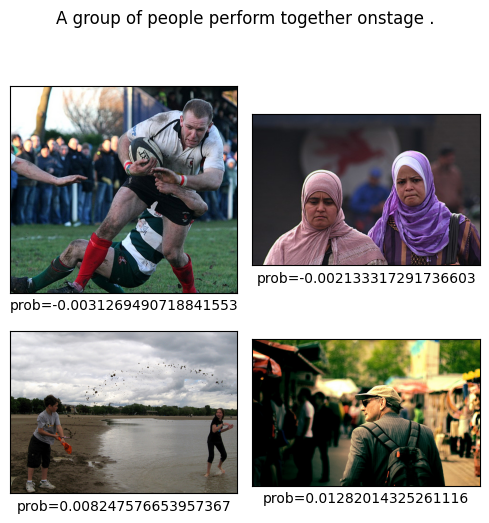

You asked for: I child slides into a wading pool full of water while an adult tosses a bucket of water on them .
This image is unavailable in your country in compliance with local laws.


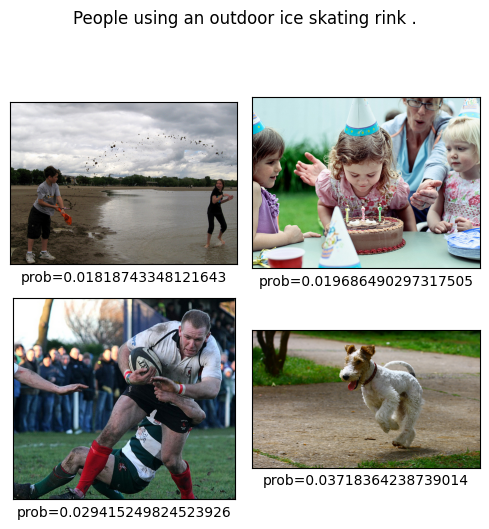

In [65]:
for i in range(9):
    show_related_images(query=random_queries[0+i:1+i])


## 8. Выводы

### Выводы по загрузке и анализу данных
Была выполнена загрузка данных: train_dataset, test_queries, test_images, ExpertAnnotations, CrowdAnnotations.

Проведена нормировка целевой переменной и агрегация оценок с акцентом на мнение экспертов.

Был построен график, который показал, что большинство описаний не соответствуют изображениям.

Был создан датасет для обучения моделей в будущем.

### Выводы по исполнению требования по ограничению обработки изображений

Был создан словарь со словами, из-за которых могут возникнуть юридические трудности, и удалили все строки, где эти слова встречаются.

### Выводы по векторизации.

Произведена векторизация изображений через Resnet50 и векторизация текстов через BERT.

Полученные эмбеддинги из всех батчей объединяются в один массив, который возвращается как результат функции.

Был получен результирующий датасет.

### Выводы по обучению модели
Была выбрана метрика RMSE исходя из целей работы моделей.

Было произведено разделение на тренировочную и валидационную выборки.

Было обучено 3 модели:

Линейной регрессии (RMSE = 0.21)                                                
CatBoost (RMSE = 0.20)                           
Полносвязная нейросеть (RMSE = 0.198)

Полносвязная нейросеть и CatBoost в итоге показали примерно одинаковый результат. Думаю, что стоит использовать полносвязную нейросеть при тестировании.

### Тестирование модели

При тестировании модели было установлено, что модель работает, но не очень хорошо, фотографии соответствуют общим деталям описания, теряя детали. Думаю, что для улучшения результатов необходимо улучшить разметку данных, возможно, увеличить выборку и дообучить нейросеть. Думаю, что в целом проект может быть реализован. 